In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Loading the dataset
df = pd.read_csv('/content/European_Bank.csv')

# **Data Understanding**

In [5]:
#Displaying the first 5 rows
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
#Shape of the dataset
df.shape

(10000, 14)

In [7]:
#Column names
df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [8]:
#Data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [9]:
#Statistical summary
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [10]:
#Check for missing values
df.isnull().sum()

,0
Year,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [11]:
#Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [12]:
#Unique countries
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [13]:
#Unique genders
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


# **Data Cleaning**

In [14]:
#Renaming columns
df.rename(columns={
    'CreditScore': 'Credit_Score',
    'NumOfProducts': 'Num_Products',
    'HasCrCard': 'Has_Credit_Card',
    'IsActiveMember': 'Is_Active_Member',
    'EstimatedSalary': 'Estimated_Salary'
}, inplace=True)

In [15]:

df.columns

Index(['Year', 'CustomerId', 'Surname', 'Credit_Score', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'Num_Products', 'Has_Credit_Card',
       'Is_Active_Member', 'Estimated_Salary', 'Exited'],
      dtype='object')

In [16]:
#Counting the number of customers who stayed and who exited
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [17]:
#Calculating the percentage of customers who stayed and exited
df['Exited'].value_counts(normalize=True) * 100

,proportion
Exited,
0,79.63
1,20.37


In [18]:
df.head()

,Year,CustomerId,Surname,Credit_Score,Geography,Gender,Age,Tenure,Balance,Num_Products,Has_Credit_Card,Is_Active_Member,Estimated_Salary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# **Exploratory Data Analysis (EDA)**

Q 1.
What is the overall customer churn rate?

/tmp/ipykernel_1849/1889085863.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Exited', palette='Set2')
/tmp/ipykernel_1849/1889085863.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Stayed', 'Exited'])


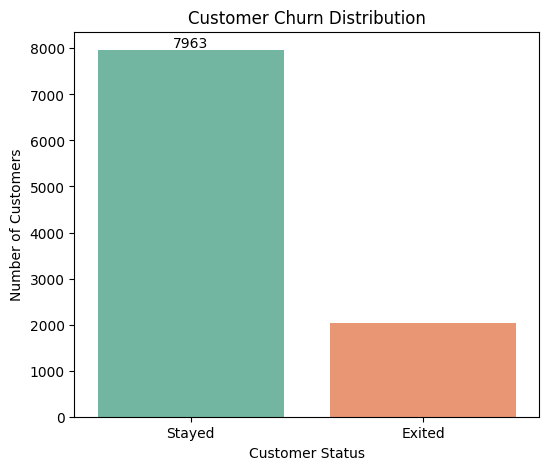

In [19]:
#Creating a count plot to visualize the number of customers who stayed and exited

plt.figure(figsize=(6,5))

ax = sns.countplot(data=df, x='Exited', palette='Set2')

ax.set_xticklabels(['Stayed', 'Exited'])


ax.bar_label(ax.containers[0])

plt.title('Customer Churn Distribution')
plt.xlabel('Customer Status')
plt.ylabel('Number of Customers')

plt.show()

### Insight & Recommendation

Most customers have remained with the bank, but a significant number have exited, indicating customer churn is an important business concern. The bank should identify high-risk customer segments and implement targeted retention strategies to improve customer loyalty and reduce churn.

Q 2.
Which country has the highest customer churn rate?

In [20]:
# Calculating the churn rate for each country
country_churn = df.groupby('Geography')['Exited'].mean() * 100

country_churn.round(2)

,Exited
Geography,
France,16.15
Germany,32.44
Spain,16.67


/tmp/ipykernel_1849/1474371398.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


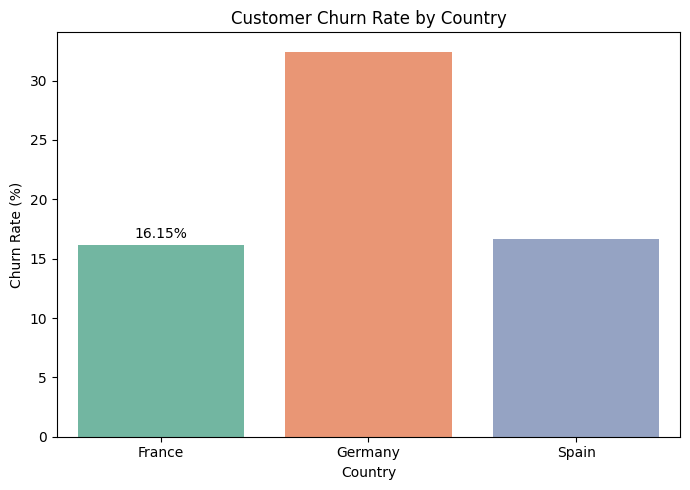

In [21]:


plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=country_churn.index,
    y=country_churn.values,
    palette='Set2'
)

ax.bar_label(ax.containers[0], fmt='%.2f%%', padding=3)

plt.title('Customer Churn Rate by Country')
plt.xlabel('Country')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

### Insight & Recommendation

Germany has the highest customer churn rate among all countries. The bank should investigate the factors contributing to churn in this region and implement targeted retention strategies.

Q 3.
Does gender influence customer churn?

In [22]:
#Calculating the churn rate for each gender
gender_churn = df.groupby('Gender')['Exited'].mean() * 100


gender_churn.round(2)


,Exited
Gender,
Female,25.07
Male,16.46


/tmp/ipykernel_1849/3718439594.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


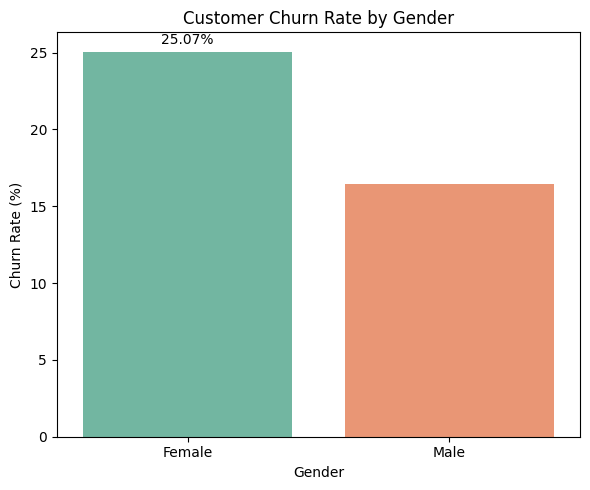

In [23]:
#Creating a bar chart to compare churn rates by gender

plt.figure(figsize=(6,5))

ax = sns.barplot(
    x=gender_churn.index,
    y=gender_churn.values,
    palette='Set2'
)


ax.bar_label(ax.containers[0], fmt='%.2f%%', padding=3)

plt.title('Customer Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

### Insight & Recommendation

Female customers have a higher churn rate than male customers. The bank should investigate the reasons behind this trend and design targeted retention strategies for the higher-risk customer group.

Q 4.
Which age groups have the highest customer churn rate?

In [24]:
#Creating age groups for analysis

df['Age_Group'] = pd.cut(df['Age'],
    bins=[18, 30, 40, 50, 60, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '60+'])


df['Age_Group'].value_counts().sort_index()

,count
Age_Group,
18-30,1946
31-40,4451
41-50,2320
51-60,797
60+,464


In [25]:
#Calculating churn rate for each age group

age_churn = df.groupby('Age_Group')['Exited'].mean() * 100


age_churn.round(2)

/tmp/ipykernel_1849/417276916.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = df.groupby('Age_Group')['Exited'].mean() * 100


,Exited
Age_Group,
18-30,7.50
31-40,12.09
41-50,33.97
51-60,56.21
60+,24.78


/tmp/ipykernel_1849/4266914247.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


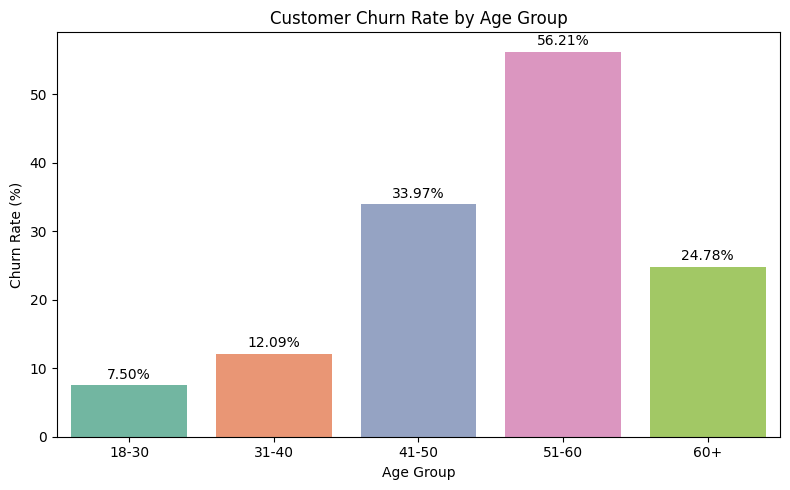

In [26]:
#Creating a bar chart to compare churn rates across age groups


plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=age_churn.index,
    y=age_churn.values,
    palette='Set2'
)


for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.2f}%',
        ha='center',
        va='bottom'
    )

plt.title('Customer Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

### Insight & Recommendation

Customers in the older age groups show a higher churn rate than younger customers. The bank should focus on personalized services, loyalty programs, and proactive customer engagement for these higher-risk age segments to improve retention.

Q 5.
Does Credit Score influence customer churn?

In [27]:
#Creating credit score groups for analysis

df['Credit_Score_Group'] = pd.cut(
    df['Credit_Score'],
    bins=[300, 500, 650, 750, 850],
    labels=['Poor', 'Fair', 'Good', 'Excellent']
)


df['Credit_Score_Group'].value_counts().sort_index()

,count
Credit_Score_Group,
Poor,643
Fair,4294
Good,3465
Excellent,1598


In [28]:
#Calculating churn rate for each credit score group

credit_churn = df.groupby('Credit_Score_Group')['Exited'].mean() * 100


credit_churn.round(2)

/tmp/ipykernel_1849/3236231659.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  credit_churn = df.groupby('Credit_Score_Group')['Exited'].mean() * 100


,Exited
Credit_Score_Group,
Poor,23.64
Fair,21.08
Good,19.25
Excellent,19.59


/tmp/ipykernel_1849/3377474045.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


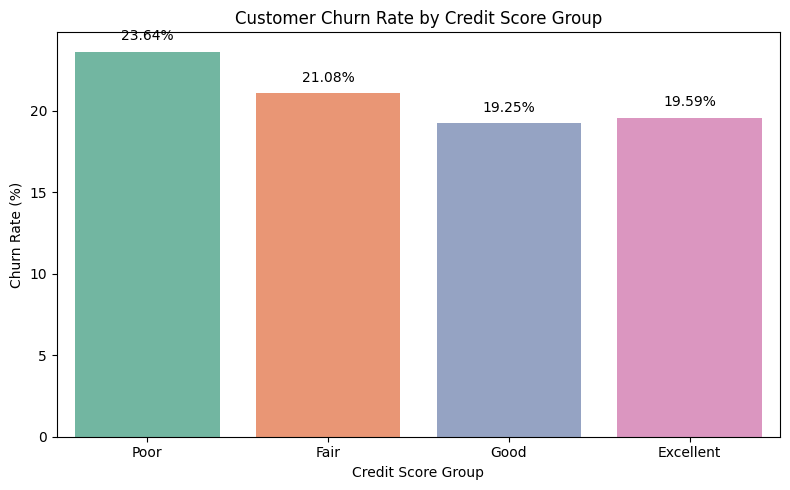

In [29]:
#Creating a bar chart to compare churn rates across credit score groups

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=credit_churn.index,
    y=credit_churn.values,
    palette='Set2'
)


for bar in ax.patches:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.2f}%',
        ha='center',
        va='bottom'
    )

plt.title('Customer Churn Rate by Credit Score Group')
plt.xlabel('Credit Score Group')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

### Insight & Recommendation

Customers with lower credit scores have a higher churn rate than those with better credit scores. The bank should strengthen customer engagement and offer personalized financial products to improve retention among higher-risk credit score segments.

Q 6.
Does account balance influence customer churn?

In [30]:
#Creating balance groups for analysis

df['Balance_Group'] = pd.cut(
    df['Balance'],
    bins=[-1, 0, 50000, 100000, 150000, 250000],
    labels=['Zero', '1-50K', '50K-100K', '100K-150K', '150K+']
)


df['Balance_Group'].value_counts().sort_index()

,count
Balance_Group,
Zero,3617
1-50K,75
50K-100K,1509
100K-150K,3830
150K+,968


In [31]:
#Calculating churn rate for each balance group

balance_churn = df.groupby('Balance_Group')['Exited'].mean() * 100


balance_churn.round(2)

/tmp/ipykernel_1849/3536244190.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  balance_churn = df.groupby('Balance_Group')['Exited'].mean() * 100


,Exited
Balance_Group,
Zero,13.82
1-50K,34.67
50K-100K,19.88
100K-150K,25.77
150K+,23.04


/tmp/ipykernel_1849/3425565049.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


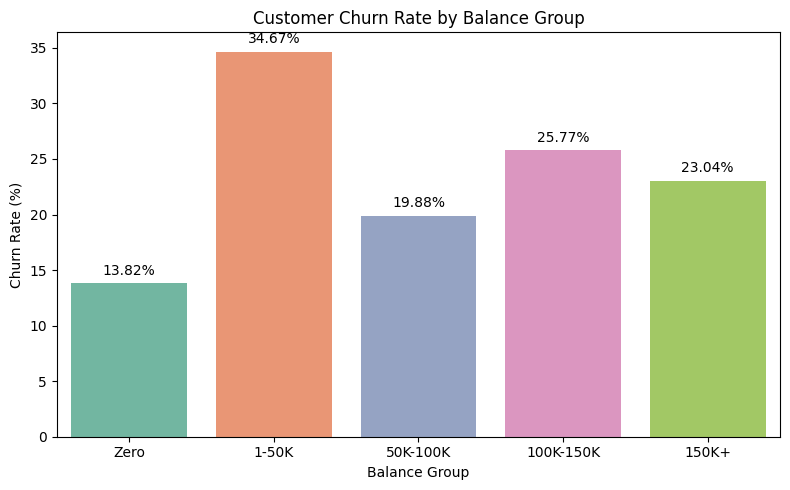

In [32]:
#Creating a bar chart to compare churn rates across balance groups

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=balance_churn.index,
    y=balance_churn.values,
    palette='Set2'
)


for bar in ax.patches:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.2f}%',
        ha='center',
        va='bottom'
    )

plt.title('Customer Churn Rate by Balance Group')
plt.xlabel('Balance Group')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

### Insight & Recommendation

Customers with higher account balances show a higher churn rate than customers with lower balances. Since these customers contribute more value to the bank, proactive engagement, personalized financial services, and exclusive loyalty benefits should be offered to improve retention.

Q 7.
Does Estimated Salary influence customer churn?

In [33]:
#Creating salary groups for analysis

df['Salary_Group'] = pd.cut(
    df['Estimated_Salary'],
    bins=[0, 50000, 100000, 150000, 200000],
    labels=['0-50K', '50K-100K', '100K-150K', '150K-200K']
)


df['Salary_Group'].value_counts().sort_index()

,count
Salary_Group,
0-50K,2453
50K-100K,2537
100K-150K,2555
150K-200K,2455


In [34]:
#Calculating churn rate for each salary group

salary_churn = df.groupby('Salary_Group')['Exited'].mean() * 100


salary_churn.round(2)

/tmp/ipykernel_1849/3960845749.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salary_churn = df.groupby('Salary_Group')['Exited'].mean() * 100


,Exited
Salary_Group,
0-50K,19.93
50K-100K,19.87
100K-150K,20.23
150K-200K,21.47


/tmp/ipykernel_1849/2974507500.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


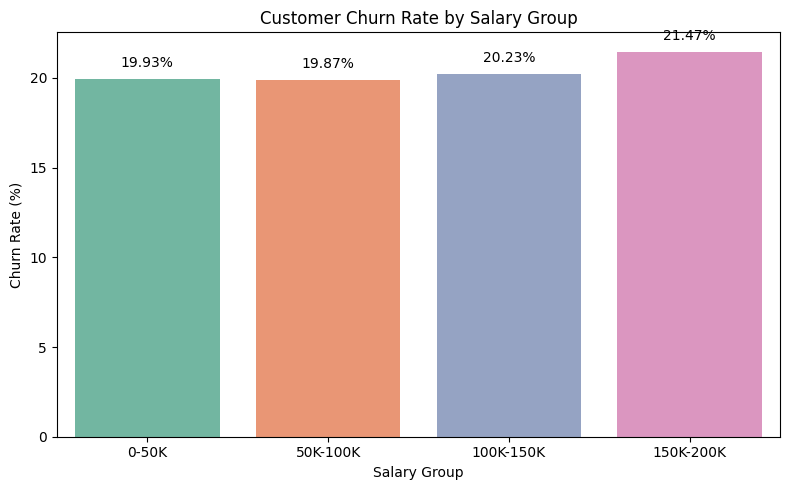

In [35]:
#Creating a bar chart to compare churn rates across salary groups

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=salary_churn.index,
    y=salary_churn.values,
    palette='Set2'
)


for bar in ax.patches:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.2f}%',
        ha='center',
        va='bottom'
    )

plt.title('Customer Churn Rate by Salary Group')
plt.xlabel('Salary Group')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

### Insight & Recommendation

Customer churn is relatively similar across different salary groups, indicating that estimated salary alone is not a strong predictor of churn. The bank should focus more on behavioral factors such as account activity, product usage, and customer engagement when designing retention strategies.

Q 8.
Does the number of products owned by a customer affect churn?

In [36]:
# Calculating churn rate for each product count

product_churn = df.groupby('Num_Products')['Exited'].mean() * 100


product_churn.round(2)

,Exited
Num_Products,
1,27.71
2,7.58
3,82.71
4,100.00


/tmp/ipykernel_1849/2359675715.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


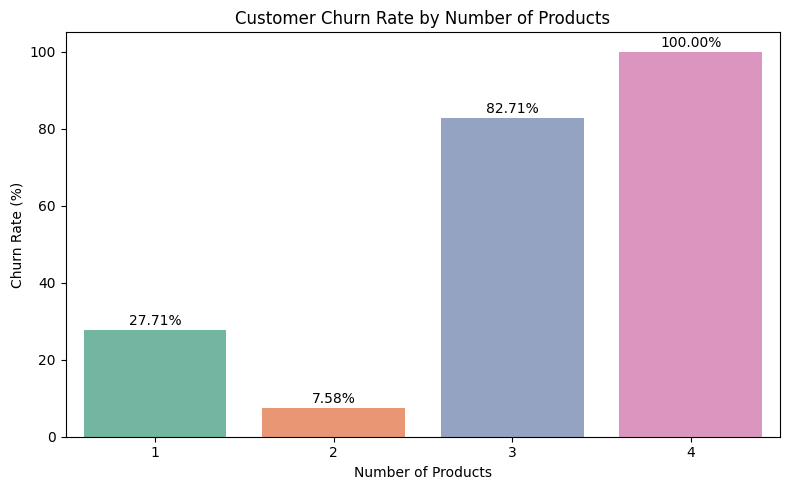

In [37]:
#Creating a bar chart to compare churn rates by number of products

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=product_churn.index,
    y=product_churn.values,
    palette='Set2'
)


for bar in ax.patches:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.2f}%',
        ha='center',
        va='bottom'
    )

plt.title('Customer Churn Rate by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

### Insight & Recommendation

Customers with three or more products have the highest churn rate, indicating that owning more products does not necessarily improve customer loyalty. The bank should investigate the reasons behind this behavior, such as product complexity, pricing, or customer experience, and strengthen engagement with these high-value customers through personalized support and retention programs.

Q 9.
Does being an active member reduce customer churn?

In [38]:
#Calculating churn rate for active and inactive customers

active_churn = df.groupby('Is_Active_Member')['Exited'].mean() * 100


active_churn.round(2)

,Exited
Is_Active_Member,
0,26.85
1,14.27


/tmp/ipykernel_1849/1043084106.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


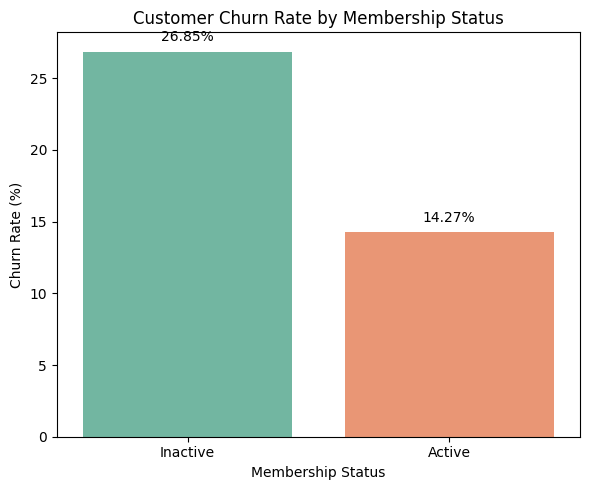

In [39]:
#Creating a bar chart to compare churn rates of active and inactive customers

plt.figure(figsize=(6,5))

ax = sns.barplot(
    x=['Inactive', 'Active'],
    y=active_churn.values,
    palette='Set2'
)


for bar in ax.patches:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.2f}%',
        ha='center',
        va='bottom'
    )

plt.title('Customer Churn Rate by Membership Status')
plt.xlabel('Membership Status')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

### Insight & Recommendation

Inactive customers have a significantly higher churn rate than active customers, indicating that customer engagement plays a major role in retention. The bank should encourage regular account usage through personalized offers, reward programs, and proactive communication to increase customer activity and reduce churn.

Q 10.
Does having a credit card influence customer churn?

In [40]:
#Calculating churn rate based on credit card ownership

creditcard_churn = df.groupby('Has_Credit_Card')['Exited'].mean() * 100


creditcard_churn.round(2)

,Exited
Has_Credit_Card,
0,20.81
1,20.18


/tmp/ipykernel_1849/3400764250.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


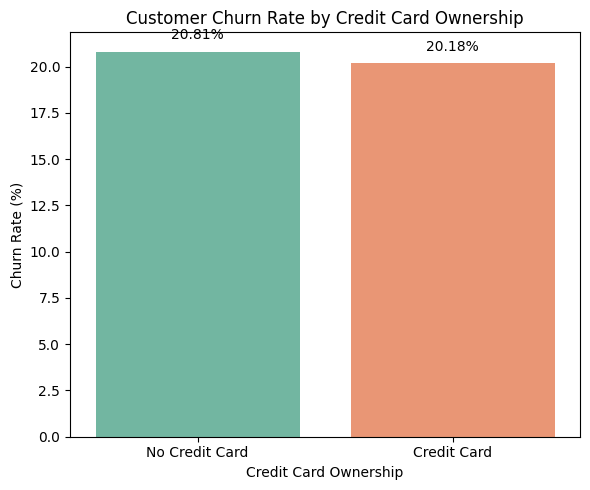

In [41]:
#Creating a bar chart to compare churn rates based on credit card ownership

plt.figure(figsize=(6,5))

ax = sns.barplot(
    x=['No Credit Card', 'Credit Card'],
    y=creditcard_churn.values,
    palette='Set2'
)


for bar in ax.patches:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.2f}%',
        ha='center',
        va='bottom'
    )

plt.title('Customer Churn Rate by Credit Card Ownership')
plt.xlabel('Credit Card Ownership')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

### Insight & Recommendation

Customers with and without a credit card show similar churn rates, suggesting that credit card ownership alone has little influence on customer retention. The bank should focus on improving customer engagement and service quality rather than relying solely on credit card offerings to reduce churn.

Q 11.
How are the numerical variables related to each other, and which factors are most strongly associated with customer churn?

In [42]:
numerical_columns = [
    'Credit_Score',
    'Age',
    'Tenure',
    'Balance',
    'Num_Products',
    'Has_Credit_Card',
    'Is_Active_Member',
    'Estimated_Salary',
    'Exited'
]

correlation_matrix = df[numerical_columns].corr()


correlation_matrix

,Credit_Score,Age,Tenure,Balance,Num_Products,Has_Credit_Card,Is_Active_Member,Estimated_Salary,Exited
Credit_Score,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
Num_Products,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
Has_Credit_Card,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
Is_Active_Member,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
Estimated_Salary,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097
Exited,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000


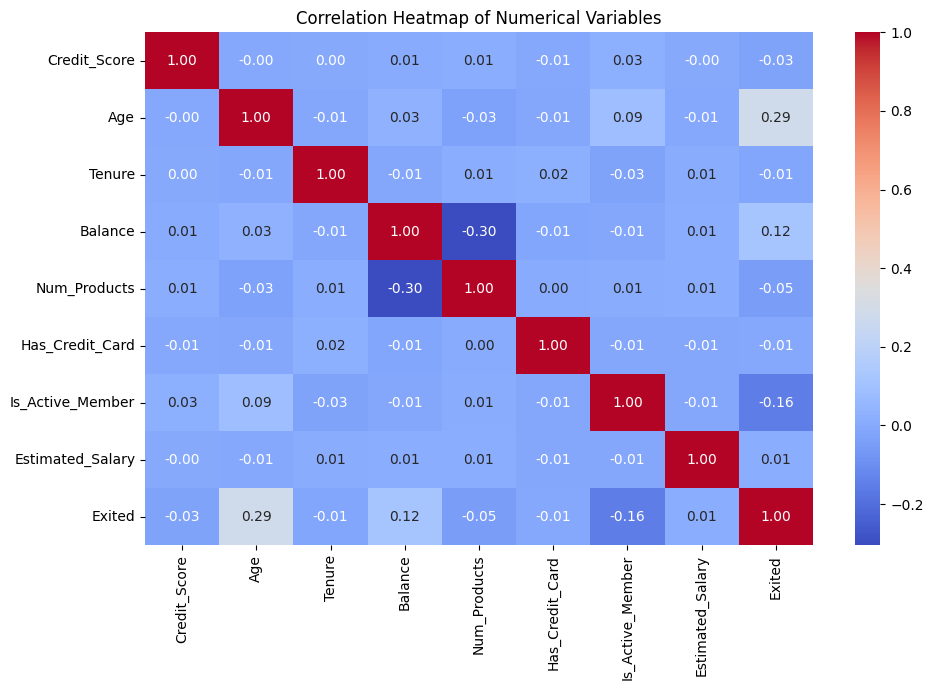

In [43]:
#Creating a correlation heatmap

plt.figure(figsize=(10,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Variables')

plt.tight_layout()
plt.show()

### Insight & Recommendation

Age and customer activity show the strongest relationships with churn, while variables such as estimated salary and credit card ownership have weak correlations. The bank should prioritize customer engagement and monitor higher-risk age groups rather than relying on demographic or financial attributes alone when developing retention strategies.

Q 12.
How is customer age distributed?

In [44]:
df['Age'].describe()

,Age
count,10000.000000
mean,38.921800
std,10.487806
min,18.000000
25%,32.000000
50%,37.000000
75%,44.000000
max,92.000000


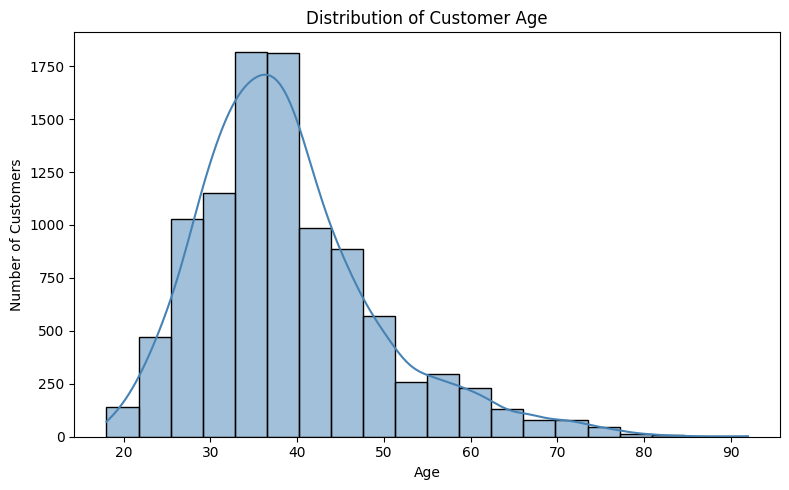

In [45]:
#Creating a histogram to visualize the distribution of customer age
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Age',
    bins=20,
    kde=True,
    color='steelblue'
)

plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

### Insight & Recommendation

Most customers fall between 30 and 45 years of age, indicating that the bank primarily serves middle-aged customers. Marketing campaigns and financial products should continue targeting this core customer segment while also identifying opportunities to attract younger customers.

Q 13.
How is customer account balance distributed?

In [46]:
df['Balance'].describe()

,Balance
count,10000.000000
mean,76485.889288
std,62397.405202
min,0.000000
25%,0.000000
50%,97198.540000
75%,127644.240000
max,250898.090000


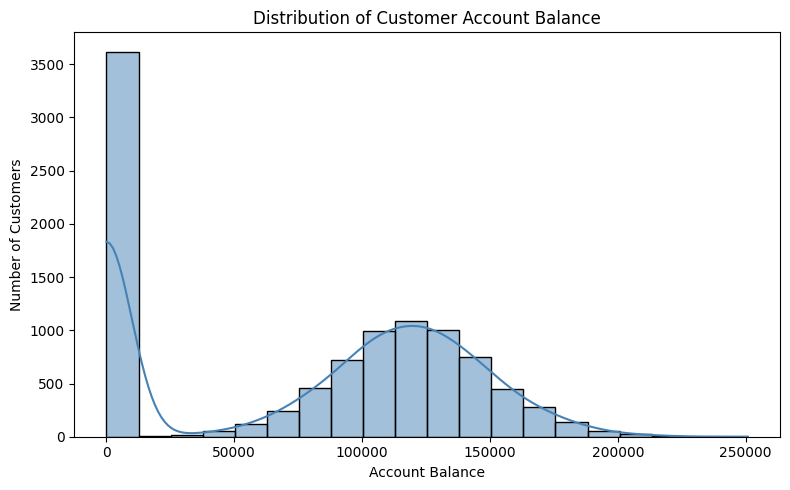

In [47]:
#Creating a histogram to visualize the distribution of customer account balances

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Balance',
    bins=20,
    kde=True,
    color='steelblue'
)

plt.title('Distribution of Customer Account Balance')
plt.xlabel('Account Balance')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

### Insight & Recommendation

The account balance distribution is not uniform, with a noticeable number of customers maintaining very low or zero balances while others hold significantly higher balances. The bank should identify customers with low balances and encourage greater account usage through personalized savings plans and promotional offers.

Q 14.
Are there any outliers in customer account balance?


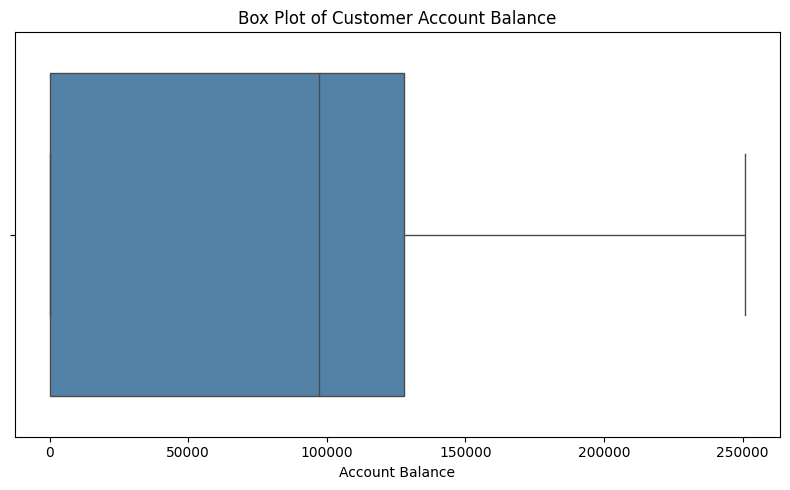

In [48]:
#Creating a box plot to identify outliers in customer account balance

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Balance',
    color='steelblue'
)

plt.title('Box Plot of Customer Account Balance')
plt.xlabel('Account Balance')

plt.tight_layout()
plt.show()

In [49]:
#Calculating the Interquartile Range (IQR)

Q1 = df['Balance'].quantile(0.25)
Q3 = df['Balance'].quantile(0.75)

IQR = Q3 - Q1

#Calculating lower and upper limits

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

#Finding the outliers

balance_outliers = df[
    (df['Balance'] < lower_limit) |
    (df['Balance'] > upper_limit)
]

print("Number of Outliers:", len(balance_outliers))

Number of Outliers: 0


### Insight & Recommendation

The box plot indicates that customer account balances do not contain significant statistical outliers based on the IQR method.

Q 15.
Do customers who churn have different age distributions compared to customers who stay?

/tmp/ipykernel_1849/985432531.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


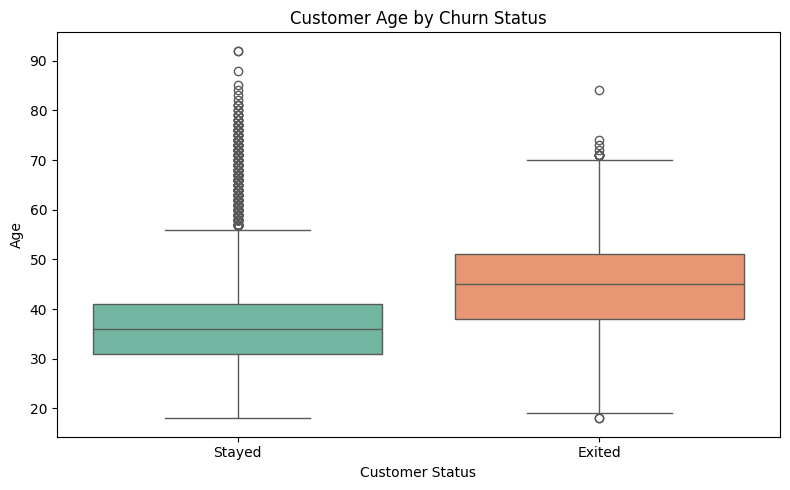

In [50]:
#Creating a box plot to compare age distribution by customer status

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Exited',
    y='Age',
    palette='Set2'
)

plt.title('Customer Age by Churn Status')
plt.xlabel('Customer Status')
plt.ylabel('Age')

plt.xticks([0, 1], ['Stayed', 'Exited'])

plt.tight_layout()
plt.show()

### Insight & Recommendation

Customers who exited the bank tend to be older than those who stayed, as indicated by a higher median age. The bank should focus on understanding the needs of older customers and develop personalized products, proactive support, and loyalty programs to improve retention within this segment.

Q 16.
Is there a relationship between customer account balance and estimated salary, and does customer churn influence this relationship?

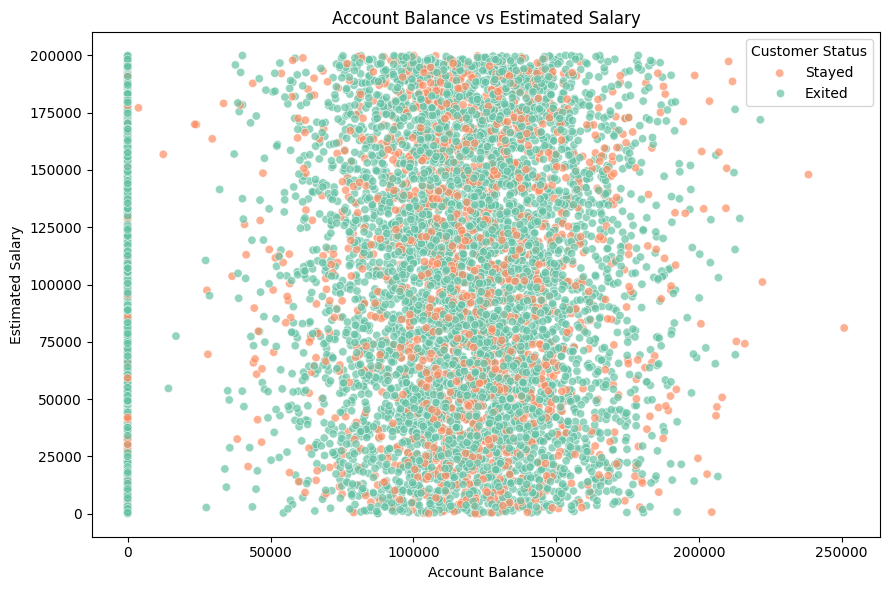

In [51]:
#Creating a scatter plot to examine the relationship between account balance and estimated salary

plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Balance',
    y='Estimated_Salary',
    hue='Exited',
    palette='Set2',
    alpha=0.7
)

plt.title('Account Balance vs Estimated Salary')
plt.xlabel('Account Balance')
plt.ylabel('Estimated Salary')

plt.legend(title='Customer Status', labels=['Stayed', 'Exited'])

plt.tight_layout()
plt.show()

### Insight & Recommendation

The scatter plot shows little to no clear relationship between customer account balance and estimated salary. Customers who exited and those who stayed are distributed across all salary and balance levels, suggesting that these two financial variables alone are not strong indicators of customer churn.

Q 17.
Which combination of Age Group and Active Membership has the highest customer churn?

/tmp/ipykernel_1849/2777460325.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df.groupby(['Age_Group', 'Is_Active_Member'])['Exited']


<Axes: xlabel='Is_Active_Member', ylabel='Age_Group'>

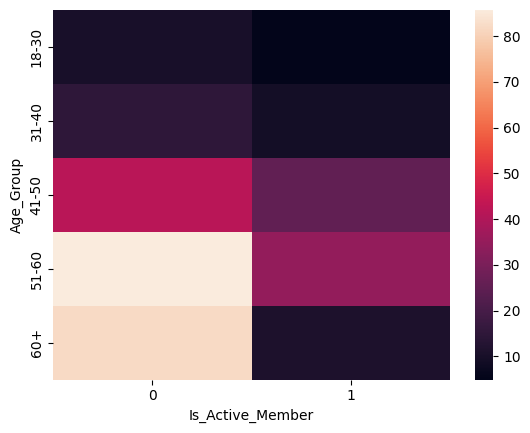

In [52]:
#Creating a pivot table to calculate churn rate for each combination of Age Group and Active Membership
churn_heatmap = (
    (df.groupby(['Age_Group', 'Is_Active_Member'])['Exited']
      .mean()*100)
    .unstack()
)

sns.heatmap(churn_heatmap)

### Insight & Recommendation

The heatmap shows that inactive customers consistently have higher churn rates across all age groups. The highest churn is observed among older inactive customers, indicating that both age and customer engagement significantly influence churn. The bank should prioritize re-engagement campaigns, personalized communication, and loyalty programs for inactive customers, particularly in older age groups.

Q 18.
Which combination of Geography and Gender has the highest customer churn?

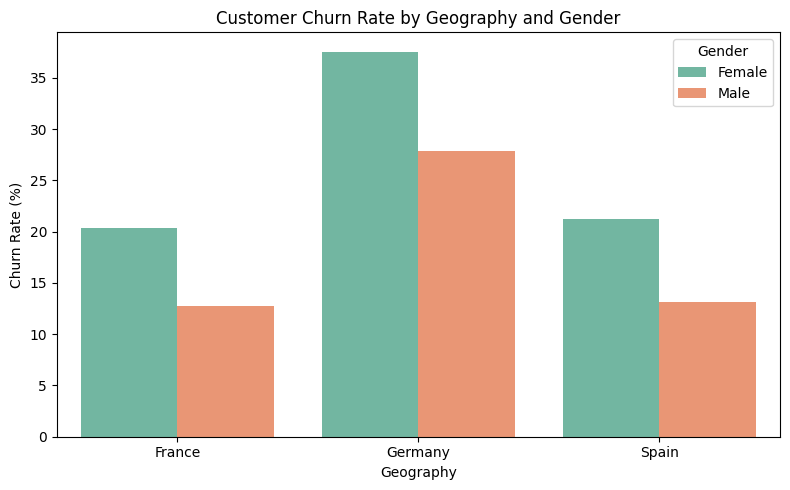

In [53]:
#Calculating churn rate by Geography and Gender

geography_gender_churn = (
    df.groupby(['Geography', 'Gender'])['Exited']
      .mean()*100
).reset_index()




plt.figure(figsize=(8,5))

sns.barplot(
    data=geography_gender_churn,
    x='Geography',
    y='Exited',
    hue='Gender',
    palette='Set2'
)

plt.title('Customer Churn Rate by Geography and Gender')
plt.xlabel('Geography')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

### Insight & Recommendation

The chart shows that customer churn varies across both geography and gender. Female customers generally exhibit higher churn rates than male customers across most countries, with Germany showing the highest churn overall. The bank should implement region-specific retention strategies and design personalized engagement programs for high-risk demographic segments.

Q 19.

Does customer tenure affect churn?

/tmp/ipykernel_1849/1260166437.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


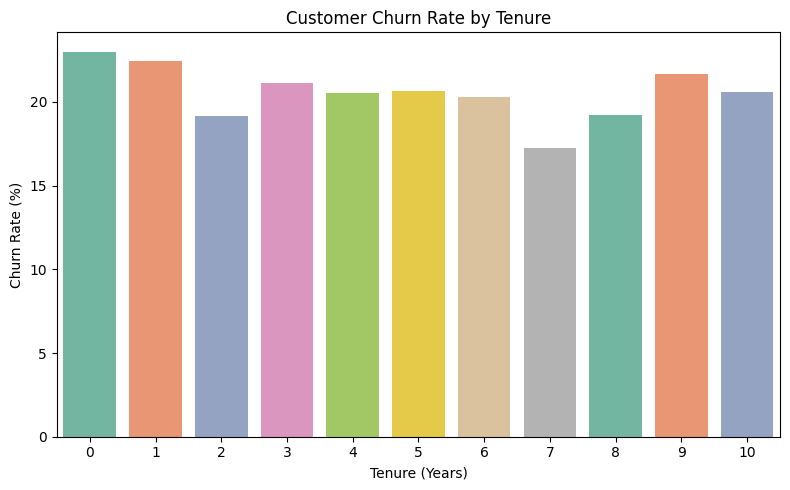

In [54]:
#Calculating churn rate by tenure

tenure_churn = (
    df.groupby('Tenure')['Exited']
      .mean() * 100
).reset_index()



plt.figure(figsize=(8,5))

sns.barplot(
    data=tenure_churn,
    x='Tenure',
    y='Exited',
    palette='Set2'
)

plt.title('Customer Churn Rate by Tenure')
plt.xlabel('Tenure (Years)')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

### Insight & Recommendation

Customer churn varies only slightly across different tenure levels.Customers with 0–1 years of tenure show the highest churn rates, while customers with 7 years of tenure have the lowest churn rate. Overall, there is no clear increasing or decreasing trend, indicating that tenure alone is not a strong predictor of customer churn.

Q 20. Which Age Group and Geography Combination Has the Highest Customer Churn Rate?

/tmp/ipykernel_1849/500211332.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df.groupby(['Age_Group', 'Geography'])['Exited']


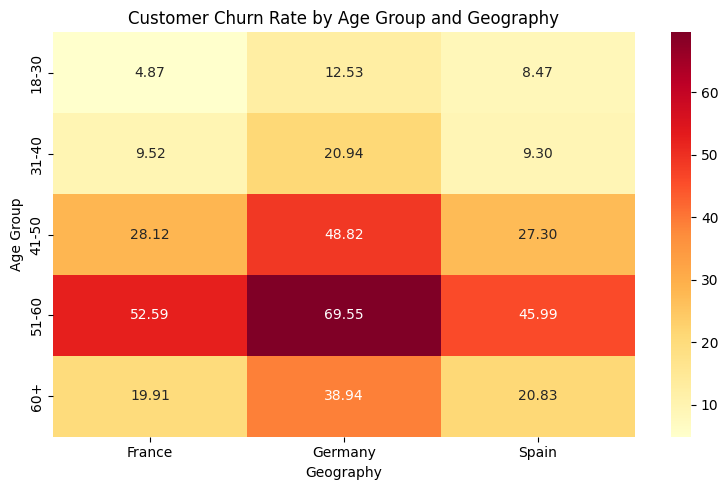

In [55]:
#Calculating churn rate by Age Group and Geography

age_geo_churn = (
    (df.groupby(['Age_Group', 'Geography'])['Exited']
       .mean() * 100)
    .unstack()
)



plt.figure(figsize=(8,5))

sns.heatmap(
    age_geo_churn,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd'
)

plt.title('Customer Churn Rate by Age Group and Geography')
plt.xlabel('Geography')
plt.ylabel('Age Group')

plt.tight_layout()
plt.show()

##Insight & Recommendation

 Customers aged 51–60, especially in Germany, have the highest churn rate, while customers aged 18–30 have the lowest. The bank should focus retention efforts on older customers in Germany through personalized offers and proactive customer engagement.

# Key Findings

- The overall customer churn rate is approximately 20%, indicating that one in every five customers leaves the bank.
- Germany has the highest churn rate among all three countries.
- Customers aged 51–60 are more likely to churn, while those aged 18–30 have the lowest churn rate.
- Inactive customers have a significantly higher churn rate than active customers.
- Customers with 3 and 4 products have the highest churn rates, while customers with 2 products have the lowest churn rate.
- Credit score, balance, salary, and tenure have relatively smaller impacts on churn compared to age and customer activity.
- Customers aged 51–60 in Germany represent the highest-risk customer segment.

# Business Recommendations

- Focus retention campaigns on customers aged **51–60**, especially those in **Germany**, as they have the highest churn rates.
- Increase customer engagement through personalized offers and loyalty programs for **inactive customers**.
- Analyze the reasons behind the high churn among customers with **3 and 4 products** and introduce targeted retention strategies for these segments.
- Regularly monitor high-risk customer segments and take proactive actions before they decide to leave.
- Continue improving customer experience and personalized banking services to strengthen long-term customer relationships.

# Conclusion

This exploratory data analysis examined the factors influencing customer churn in a European bank. The analysis revealed that customer age, geography, activity status, and number of products have a stronger association with churn than factors such as tenure, balance, or salary. In particular, customers aged 51–60 in Germany and inactive customers showed the highest risk of churn. These insights can help the bank identify high-risk customer segments and develop targeted retention strategies to improve customer loyalty and reduce churn.